In [0]:
import pandas as pd
import numpy as np

from pyspark.sql import functions as F
from sklearn.model_selection import train_test_split

FILE_PATH = "/Volumes/workspace/default/football_data/Football.csv"

TRAIN_PATH = (
    "/Volumes/workspace/default/football_data/"
    "football_train.csv"
)

TEST_PATH = (
    "/Volumes/workspace/default/football_data/"
    "football_test.csv"
)

METADATA_PATH = (
    "/Volumes/workspace/default/football_data/"
    "data_metadata.csv"
)

RANDOM_STATE = 42
MAX_ROWS = 20_000
TEST_SIZE = 0.20
TARGET = "match_result"

print("Configuration completed.")

Configuration completed.


In [0]:
football_spark_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("escape", '"')
    .csv(FILE_PATH)
)

print("Original rows:", football_spark_df.count())
print("Original columns:", len(football_spark_df.columns))

display(football_spark_df.limit(5))

Original rows: 95384
Original columns: 91


Country,League,home_team,away_team,home_score,away_score,season_year,Date_day,Date_hour,first_half,second_half,home_team_goals_current_time,home_team_goals_current_score,home_team_goals,home_team_goals_assist,away_team_goals_current_time,away_team_goals_current_score,away_team_goals,away_team_goals_assist,home_team_yellow_card_current_time,home_team_yellow_card,home_team_yellow_card_why,away_team_yellow_card_current_time,away_team_yellow_card,away_team_yellow_card_why,home_team_red_card_current_time,home_team_red_card,home_team_red_card_why,away_team_red_card_current_time,away_team_red_card,away_team_red_card_why,home_team_substitutions_current_time,home_team_substitutions,home_team_substitutions_with,home_team_substitution_why,away_team_substitutions_current_time,away_team_substitutions,away_team_substitutions_with,away_team_substitution_why,expected_goals_xg_home,expected_goals_xg_host,Ball_Possession_Home,Ball_Possession_Host,Goal_Attempts_Home,Goal_Attempts_Host,Shots_on_Goal_Home,Shots_on_Goal_Host,Shots_off_Goal_Home,Shots_off_Goal_Host,Blocked_Shots_Home,Blocked_Shots_Host,Free_Kicks_Home,Free_Kicks_Host,Corner_Kicks_Home,Corner_Kicks_Host,Offsides_Home,Offsides_Host,Throw_ins_Home,Throw_ins_Host,Goalkeeper_Saves_Home,Goalkeeper_Saves_Host,Fouls_Home,Fouls_Host,Red_Cards_Home,Red_Cards_Host,Yellow_Cards_Home,Yellow_Cards_Host,Total_Passes_Home,Total_Passes_Host,Completed_Passes_Home,Completed_Passes_Host,Tackles_Home,Tackles_Host,Crosses_Completed_Home,Crosses_Completed_Host,Interceptions_Home,Interceptions_Host,Attacks_Home,Attacks_Host,Dangerous_Attacks_Home,Dangerous_Attacks_Host,Distance_Covered_(km)_Home,Distance_Covered_(km)_Host,Clearances_Completed_Home,Clearances_Completed_Host,Pass_Success_per_Home,Pass_Success_per_Host,referee,venue,capacity,attendance
Germany,Bundesliga,B. Monchengladbach,Werder Bremen,4,1,2024/2025,3.11,2026-07-24T19:30:00.000Z,3 - 0,1 - 1,"[""11'"", ""12'"", ""45'"", ""66'""]","['1 - 0', '2 - 0', '3 - 0', '4 - 0']","['Plea A.', 'Friedl M.', 'Honorat F.', 'Stoger K.']","['(Kleindienst T.)', '(Own goal)', '(Kleindienst T.)', '(Kleindienst T.)']","[""75'""]",['4 - 1'],['Topp K.'],['(Ducksch M.)'],"[""79'""]",['Itakura K.'],['(Roughing)'],"[""19'"", ""22'"", ""53'""]","['Agu F.', 'Weiser M.', 'Lynen S.']","['(Roughing)', '(Foul)', '(Foul)']",null,null,null,"[""82'""]",['Weiser M.'],['(Foul)'],"[""63'"", ""71'"", ""71'"", ""77'"", ""77'""]","['Stoger K.', 'Neuhaus F.', 'Cvancara T.', 'Chiarodia F. C.', 'Ngoumou N.']","['Plea A.', 'Hack R.', 'Kleindienst T.', 'Ullrich L.', 'Honorat F.']","['-', '-', '-', '-', '-']","[""46'"", ""46'"", ""46'"", ""68'"", ""81'""]","['Veljkovic M.', 'Jung A.', 'Kohn D.', 'Topp K.', 'Burke O.']","['Malatini J.', 'Pieper A.', 'Agu F.', 'Njinmah J.', 'Bittencourt L.']","['-', '-', '-', '-', '-']",2.39,1.46,47%,53%,16.0,15.0,8.0,5.0,7.0,5.0,1.0,5.0,10.0,12.0,7.0,7.0,2.0,1.0,20.0,20.0,4.0,4.0,12.0,10.0,0.0,1.0,1.0,4.0,479.0,549.0,395.0,453.0,90.0,99.0,5.0,7.0,12.0,11.0,null,null,null,null,null,null,null,null,null,null,Dankert B. (Ger),Borussia-Park (Mönchengladbach),54 042,54 042
Germany,Bundesliga,Freiburg,Mainz,0,0,2024/2025,3.11,2026-07-24T17:30:00.000Z,0 - 0,0 - 0,null,null,null,null,null,null,null,null,"[""90+2'""]",['Sildillia K.'],['(Roughing)'],"[""44'"", ""70'""]","['Lee Jae-Sung', 'Bell S.']","['(Foul)', '(Roughing)']",null,null,null,null,null,null,"[""66'"", ""66'"", ""66'"", ""72'"", ""88'""]","['Hofler N.', 'Weisshaupt N.', 'Rosenfelder M.', 'Gregoritsch M.', 'Sildillia K.']","['Eggestein M.', 'Grifo V.', 'Lienhart P.', 'Adamu J.', 'Doan R.']","['-', '-', '-', '-', '-']","[""46'"", ""74'"", ""90'"", ""90+3'""]","['Sieb A.', 'Hong Hyun-Seok', 'Widmer S.', 'Veratschnig N.']","['Burkardt J.', 'Amiri N.', 'Caci A.', 'Nebel P.']","['-', '-', '-', '-']",0.77,0.53,51%,49%,10.0,9.0,2.0,2.0,3.0,5.0,5.0,2.0,12.0,9.0,8.0,4.0,2.0,2.0,22.0,18.0,2.0,2.0,9.0,12.0,null,null,1.0,2.0,471.0,443.0,377.0,362.0,83.0,87.0,3.0,3.0,8.0,15.0,null,null,null,null,null,null,null,null,n

In [0]:
sampled_spark_df = (
    football_spark_df
    .orderBy(F.rand(seed=RANDOM_STATE))
    .limit(MAX_ROWS)
)

sampled_rows = sampled_spark_df.count()

print("Sampled rows:", sampled_rows)

assert sampled_rows <= MAX_ROWS

Sampled rows: 20000


In [0]:
df = sampled_spark_df.toPandas()

print("Pandas dataset shape:", df.shape)

Pandas dataset shape: (20000, 91)


In [0]:
required_score_columns = [
    "home_score",
    "away_score"
]

missing_score_columns = [
    column
    for column in required_score_columns
    if column not in df.columns
]

if missing_score_columns:
    raise ValueError(
        f"Required score columns are missing: "
        f"{missing_score_columns}"
    )

print("Score columns found successfully.")

Score columns found successfully.


In [0]:
display(
    df[
        [
            "home_team",
            "away_team",
            "home_score",
            "away_score"
        ]
    ].head(10)
)

home_team,away_team,home_score,away_score
Clapton,Needham Market,0,3
Bolton,Newcastle,0,2
Laval,Pau FC,3,1
Reggina,Ascoli,0,0
Brentford,Arsenal,0,3
Le Havre,Chateauroux,0,3
Stade Montois,Genets,2,1
Eintracht Frankfurt,Bochum,7,2
Cottbus,Munich 1860,1,1
Altay,Mersin,1,1


In [0]:
df["home_score"] = pd.to_numeric(
    df["home_score"],
    errors="coerce"
)

df["away_score"] = pd.to_numeric(
    df["away_score"],
    errors="coerce"
)

print(
    "Missing home scores:",
    df["home_score"].isna().sum()
)

print(
    "Missing away scores:",
    df["away_score"].isna().sum()
)

Missing home scores: 1
Missing away scores: 1


In [0]:
conditions = [
    df["home_score"] > df["away_score"],
    df["home_score"] < df["away_score"]
]

choices = [
    "Home Win",
    "Away Win"
]

df[TARGET] = np.select(
    conditions,
    choices,
    default="Draw"
)

In [0]:
display(
    df[
        [
            "home_team",
            "away_team",
            "home_score",
            "away_score",
            TARGET
        ]
    ].head(15)
)

home_team,away_team,home_score,away_score,match_result
Clapton,Needham Market,0.0,3.0,Away Win
Bolton,Newcastle,0.0,2.0,Away Win
Laval,Pau FC,3.0,1.0,Home Win
Reggina,Ascoli,0.0,0.0,Draw
Brentford,Arsenal,0.0,3.0,Away Win
Le Havre,Chateauroux,0.0,3.0,Away Win
Stade Montois,Genets,2.0,1.0,Home Win
Eintracht Frankfurt,Bochum,7.0,2.0,Home Win
Cottbus,Munich 1860,1.0,1.0,Draw
Altay,Mersin,1.0,1.0,Draw


In [0]:
target_distribution = (
    df[TARGET]
    .value_counts()
    .rename_axis("match_result")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"]
    / len(df)
    * 100
).round(2)

display(target_distribution)

match_result,count,percentage
Home Win,9068,45.34
Away Win,6118,30.59
Draw,4814,24.07


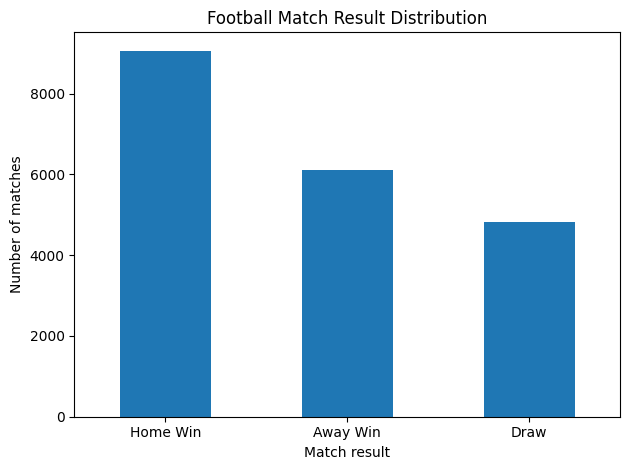

In [0]:
import matplotlib.pyplot as plt

df[TARGET].value_counts().plot(
    kind="bar",
    title="Football Match Result Distribution"
)

plt.xlabel("Match result")
plt.ylabel("Number of matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [0]:
leakage_columns = [
    # Direct target leakage
    "home_score",
    "away_score",

    # Half-time and match-score information
    "first_half",
    "second_half",

    # Goal event information
    "home_team_goals_current_time",
    "home_team_goals_current_score",
    "home_team_goals",
    "home_team_goals_assist",
    "away_team_goals_current_time",
    "away_team_goals_current_score",
    "away_team_goals",
    "away_team_goals_assist",

    # Card event descriptions and timestamps
    "home_team_yellow_card_current_time",
    "home_team_yellow_card",
    "home_team_yellow_card_why",
    "away_team_yellow_card_current_time",
    "away_team_yellow_card",
    "away_team_yellow_card_why",

    "home_team_red_card_current_time",
    "home_team_red_card",
    "home_team_red_card_why",
    "away_team_red_card_current_time",
    "away_team_red_card",
    "away_team_red_card_why",

    # Substitution event details
    "home_team_substitutions_current_time",
    "home_team_substitutions",
    "home_team_substitutions_with",
    "home_team_substitution_why",
    "away_team_substitutions_current_time",
    "away_team_substitutions",
    "away_team_substitutions_with",
    "away_team_substitution_why"
]

existing_leakage_columns = [
    column
    for column in leakage_columns
    if column in df.columns
]

print("Leakage columns excluded:")
for column in existing_leakage_columns:
    print(column)

Leakage columns excluded:
home_score
away_score
first_half
second_half
home_team_goals_current_time
home_team_goals_current_score
home_team_goals
home_team_goals_assist
away_team_goals_current_time
away_team_goals_current_score
away_team_goals
away_team_goals_assist
home_team_yellow_card_current_time
home_team_yellow_card
home_team_yellow_card_why
away_team_yellow_card_current_time
away_team_yellow_card
away_team_yellow_card_why
home_team_red_card_current_time
home_team_red_card
home_team_red_card_why
away_team_red_card_current_time
away_team_red_card
away_team_red_card_why
home_team_substitutions_current_time
home_team_substitutions
home_team_substitutions_with
home_team_substitution_why
away_team_substitutions_current_time
away_team_substitutions
away_team_substitutions_with
away_team_substitution_why


In [0]:
candidate_features = [
    # General context
    "Country",
    "League",
    "home_team",
    "away_team",
    "season_year",

    # Expected goals
    "expected_goals_xg_home",
    "expected_goals_xg_host",

    # Possession
    "Ball_Possession_Home",
    "Ball_Possession_Host",

    # Attempts and shots
    "Goal_Attempts_Home",
    "Goal_Attempts_Host",
    "Shots_on_Goal_Home",
    "Shots_on_Goal_Host",
    "Shots_off_Goal_Home",
    "Shots_off_Goal_Host",
    "Blocked_Shots_Home",
    "Blocked_Shots_Host",

    # Set pieces
    "Free_Kicks_Home",
    "Free_Kicks_Host",
    "Corner_Kicks_Home",
    "Corner_Kicks_Host",
    "Offsides_Home",
    "Offsides_Host",
    "Throw_ins_Home",
    "Throw_ins_Host",

    # Defensive actions
    "Goalkeeper_Saves_Home",
    "Goalkeeper_Saves_Host",
    "Fouls_Home",
    "Fouls_Host",
    "Red_Cards_Home",
    "Red_Cards_Host",
    "Yellow_Cards_Home",
    "Yellow_Cards_Host",
    "Tackles_Home",
    "Tackles_Host",
    "Interceptions_Home",
    "Interceptions_Host",
    "Clearances_Completed_Home",
    "Clearances_Completed_Host",

    # Passing
    "Total_Passes_Home",
    "Total_Passes_Host",
    "Completed_Passes_Home",
    "Completed_Passes_Host",
    "Pass_Success_per_Home",
    "Pass_Success_per_Host",

    # Attacking activity
    "Crosses_Completed_Home",
    "Crosses_Completed_Host",
    "Attacks_Home",
    "Attacks_Host",
    "Dangerous_Attacks_Home",
    "Dangerous_Attacks_Host",

    # Physical statistics
    "Distance_Covered_(km)_Home",
    "Distance_Covered_(km)_Host",

    # Match context
    "referee",
    "venue",
    "capacity",
    "attendance"
]

In [0]:
available_features = [
    column
    for column in candidate_features
    if column in df.columns
]

missing_features = [
    column
    for column in candidate_features
    if column not in df.columns
]

print("Available features:", len(available_features))
print("Missing features:", len(missing_features))

if missing_features:
    print("\nMissing feature names:")
    for column in missing_features:
        print(column)

Available features: 57
Missing features: 0


In [0]:
model_df = df[
    available_features + [TARGET]
].copy()

print("Shape before cleaning:", model_df.shape)

Shape before cleaning: (20000, 58)


In [0]:
duplicate_count = model_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

model_df = model_df.drop_duplicates()
model_df = model_df.reset_index(drop=True)

print("Shape after duplicate removal:", model_df.shape)

Duplicate rows: 1
Shape after duplicate removal: (19999, 58)


In [0]:
def clean_numeric_column(series):
    if series.dtype == "object":
        series = (
            series.astype(str)
            .str.replace("%", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip()
        )

        series = series.replace(
            {
                "": np.nan,
                "None": np.nan,
                "nan": np.nan,
                "-": np.nan
            }
        )

    return pd.to_numeric(
        series,
        errors="coerce"
    )

In [0]:
numeric_feature_columns = [
    "season_year",
    "expected_goals_xg_home",
    "expected_goals_xg_host",
    "Ball_Possession_Home",
    "Ball_Possession_Host",
    "Goal_Attempts_Home",
    "Goal_Attempts_Host",
    "Shots_on_Goal_Home",
    "Shots_on_Goal_Host",
    "Shots_off_Goal_Home",
    "Shots_off_Goal_Host",
    "Blocked_Shots_Home",
    "Blocked_Shots_Host",
    "Free_Kicks_Home",
    "Free_Kicks_Host",
    "Corner_Kicks_Home",
    "Corner_Kicks_Host",
    "Offsides_Home",
    "Offsides_Host",
    "Throw_ins_Home",
    "Throw_ins_Host",
    "Goalkeeper_Saves_Home",
    "Goalkeeper_Saves_Host",
    "Fouls_Home",
    "Fouls_Host",
    "Red_Cards_Home",
    "Red_Cards_Host",
    "Yellow_Cards_Home",
    "Yellow_Cards_Host",
    "Total_Passes_Home",
    "Total_Passes_Host",
    "Completed_Passes_Home",
    "Completed_Passes_Host",
    "Tackles_Home",
    "Tackles_Host",
    "Crosses_Completed_Home",
    "Crosses_Completed_Host",
    "Interceptions_Home",
    "Interceptions_Host",
    "Attacks_Home",
    "Attacks_Host",
    "Dangerous_Attacks_Home",
    "Dangerous_Attacks_Host",
    "Distance_Covered_(km)_Home",
    "Distance_Covered_(km)_Host",
    "Clearances_Completed_Home",
    "Clearances_Completed_Host",
    "Pass_Success_per_Home",
    "Pass_Success_per_Host",
    "capacity",
    "attendance"
]

In [0]:
converted_columns = []

for column in numeric_feature_columns:
    if column in model_df.columns:
        model_df[column] = clean_numeric_column(
            model_df[column]
        )
        converted_columns.append(column)

print("Numeric columns converted:", len(converted_columns))

Numeric columns converted: 51


In [0]:
data_types = pd.DataFrame({
    "column": model_df.columns,
    "dtype": model_df.dtypes.astype(str).values,
    "missing_count": model_df.isna().sum().values
})

display(data_types)

column,dtype,missing_count
Country,object,0
League,object,0
home_team,object,0
away_team,object,0
season_year,float64,19999
expected_goals_xg_home,float64,18927
expected_goals_xg_host,float64,18927
Ball_Possession_Home,float64,12088
Ball_Possession_Host,float64,12088
Goal_Attempts_Home,float64,11934


In [0]:
missing_summary = (
    model_df
    .isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = [
    "column",
    "missing_count"
]

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(model_df)
    * 100
).round(2)

display(missing_summary.head(30))

column,missing_count,missing_percentage
capacity,19999,100.0
season_year,19999,100.0
Pass_Success_per_Home,19999,100.0
Pass_Success_per_Host,19999,100.0
attendance,19952,99.76
Crosses_Completed_Home,19906,99.53
Crosses_Completed_Host,19906,99.53
Distance_Covered_(km)_Host,19882,99.41
Distance_Covered_(km)_Home,19882,99.41
Clearances_Completed_Host,19864,99.32


In [0]:
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15999, 57)
X_test shape: (4000, 57)
y_train shape: (15999,)
y_test shape: (4000,)


In [0]:
train_distribution = (
    y_train
    .value_counts(normalize=True)
    .round(4)
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .round(4)
)

print("Training target distribution:")
print(train_distribution)

print("\nTest target distribution:")
print(test_distribution)

Training target distribution:
match_result
Home Win    0.4534
Away Win    0.3059
Draw        0.2407
Name: proportion, dtype: float64

Test target distribution:
match_result
Home Win    0.4535
Away Win    0.3058
Draw        0.2408
Name: proportion, dtype: float64


In [0]:
train_df = X_train.copy()
train_df[TARGET] = y_train

test_df = X_test.copy()
test_df[TARGET] = y_test

train_df.to_csv(
    TRAIN_PATH,
    index=False
)

test_df.to_csv(
    TEST_PATH,
    index=False
)

print("Training data saved to:")
print(TRAIN_PATH)

print("\nTest data saved to:")
print(TEST_PATH)

Training data saved to:
/Volumes/workspace/default/football_data/football_train.csv

Test data saved to:
/Volumes/workspace/default/football_data/football_test.csv


In [0]:
metadata = pd.DataFrame({
    "property": [
        "source_file",
        "random_state",
        "maximum_rows",
        "final_rows",
        "training_rows",
        "test_rows",
        "number_of_features",
        "target_column",
        "test_size"
    ],
    "value": [
        str(FILE_PATH),
        str(RANDOM_STATE),
        str(MAX_ROWS),
        str(len(model_df)),
        str(len(train_df)),
        str(len(test_df)),
        str(len(available_features)),
        str(TARGET),
        str(TEST_SIZE)
    ]
})

metadata.to_csv(
    METADATA_PATH,
    index=False
)

display(metadata)

property,value
source_file,/Volumes/workspace/default/football_data/Football.csv
random_state,42
maximum_rows,20000
final_rows,19999
training_rows,15999
test_rows,4000
number_of_features,57
target_column,match_result
test_size,0.2


In [0]:
saved_train_df = pd.read_csv(TRAIN_PATH)
saved_test_df = pd.read_csv(TEST_PATH)

print("Saved training shape:", saved_train_df.shape)
print("Saved test shape:", saved_test_df.shape)

assert len(saved_train_df) == len(train_df)
assert len(saved_test_df) == len(test_df)

assert TARGET in saved_train_df.columns
assert TARGET in saved_test_df.columns

assert "home_score" not in saved_train_df.columns
assert "away_score" not in saved_train_df.columns

print("\nAll frozen-data checks passed.")

Saved training shape: (15999, 58)
Saved test shape: (4000, 58)

All frozen-data checks passed.


In [0]:
import os
import pandas as pd
import mlflow

# =====================================================
# Configuration
# =====================================================

TRAIN_PATH = "/Volumes/workspace/default/football_data/football_train.csv"
TEST_PATH = "/Volumes/workspace/default/football_data/football_test.csv"
METADATA_PATH = "/Volumes/workspace/default/football_data/data_metadata.csv"

TARGET = "match_result"

print("=" * 60)
print("PROJECT VERIFICATION CHECKLIST")
print("=" * 60)

# =====================================================
# Check files
# =====================================================

print("\n1. Checking files...")

files = {
    "football_train.csv": TRAIN_PATH,
    "football_test.csv": TEST_PATH,
    "data_metadata.csv": METADATA_PATH
}

all_files_exist = True

for name, path in files.items():
    exists = os.path.exists(path)
    print(f"{name:<25}: {'✅ Found' if exists else '❌ Missing'}")
    if not exists:
        all_files_exist = False

if not all_files_exist:
    raise FileNotFoundError(
        "One or more required files are missing."
    )

# =====================================================
# Load datasets
# =====================================================

print("\n2. Loading datasets...")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Training Shape : {train_df.shape}")
print(f"Testing Shape  : {test_df.shape}")

# =====================================================
# Check target column
# =====================================================

print("\n3. Checking target column...")

if TARGET in train_df.columns:
    print(f"✅ Target column '{TARGET}' exists in training data")
else:
    raise ValueError(f"❌ {TARGET} missing from training data")

if TARGET in test_df.columns:
    print(f"✅ Target column '{TARGET}' exists in testing data")
else:
    raise ValueError(f"❌ {TARGET} missing from testing data")

# =====================================================
# Check leakage columns
# =====================================================

print("\n4. Checking leakage columns...")

leakage = ["home_score", "away_score"]

for col in leakage:
    if col in train_df.columns:
        print(f"❌ Leakage column found: {col}")
    else:
        print(f"✅ {col} removed")

# =====================================================
# Feature summary
# =====================================================

print("\n5. Feature Summary")

X = train_df.drop(columns=[TARGET])

numeric = X.select_dtypes(include="number").columns.tolist()
categorical = X.select_dtypes(exclude="number").columns.tolist()

print(f"Total Features      : {len(X.columns)}")
print(f"Numeric Features    : {len(numeric)}")
print(f"Categorical Features: {len(categorical)}")

# =====================================================
# Missing values
# =====================================================

print("\n6. Missing Values")

missing = X.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ No missing values")
else:
    print(missing.sort_values(ascending=False))

# =====================================================
# Target distribution
# =====================================================

print("\n7. Target Distribution")

print(train_df[TARGET].value_counts())

# =====================================================
# MLflow
# =====================================================

print("\n8. MLflow")

print("Tracking URI :", mlflow.get_tracking_uri())

# =====================================================
# Preview
# =====================================================

print("\n9. Preview")

display(train_df.head())

print("\n" + "=" * 60)
print("✅ PROJECT IS READY FOR NOTEBOOK 3")
print("=" * 60)

PROJECT VERIFICATION CHECKLIST

1. Checking files...
football_train.csv       : ✅ Found
football_test.csv        : ✅ Found
data_metadata.csv        : ✅ Found

2. Loading datasets...
Training Shape : (15999, 58)
Testing Shape  : (4000, 58)

3. Checking target column...
✅ Target column 'match_result' exists in training data
✅ Target column 'match_result' exists in testing data

4. Checking leakage columns...
✅ home_score removed
✅ away_score removed

5. Feature Summary
Total Features      : 57
Numeric Features    : 51
Categorical Features: 6

6. Missing Values
season_year                   15999
Pass_Success_per_Home         15999
capacity                      15999
Pass_Success_per_Host         15999
attendance                    15961
Crosses_Completed_Host        15925
Crosses_Completed_Home        15925
Distance_Covered_(km)_Host    15903
Distance_Covered_(km)_Home    15903
Clearances_Completed_Host     15887
Clearances_Completed_Home     15887
Interceptions_Host            15843
Int

Country,League,home_team,away_team,season_year,expected_goals_xg_home,expected_goals_xg_host,Ball_Possession_Home,Ball_Possession_Host,Goal_Attempts_Home,Goal_Attempts_Host,Shots_on_Goal_Home,Shots_on_Goal_Host,Shots_off_Goal_Home,Shots_off_Goal_Host,Blocked_Shots_Home,Blocked_Shots_Host,Free_Kicks_Home,Free_Kicks_Host,Corner_Kicks_Home,Corner_Kicks_Host,Offsides_Home,Offsides_Host,Throw_ins_Home,Throw_ins_Host,Goalkeeper_Saves_Home,Goalkeeper_Saves_Host,Fouls_Home,Fouls_Host,Red_Cards_Home,Red_Cards_Host,Yellow_Cards_Home,Yellow_Cards_Host,Tackles_Home,Tackles_Host,Interceptions_Home,Interceptions_Host,Clearances_Completed_Home,Clearances_Completed_Host,Total_Passes_Home,Total_Passes_Host,Completed_Passes_Home,Completed_Passes_Host,Pass_Success_per_Home,Pass_Success_per_Host,Crosses_Completed_Home,Crosses_Completed_Host,Attacks_Home,Attacks_Host,Dangerous_Attacks_Home,Dangerous_Attacks_Host,Distance_Covered_(km)_Home,Distance_Covered_(km)_Host,referee,venue,capacity,attendance,match_result
Germany,Dfb-pokal,Eintracht Frankfurt,Bayern Munich,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Deutsche Bank Park (Frankfurt),null,null,Away Win
France,Ligue-1,Rennes,Bastia,null,null,null,66.0,34.0,12.0,14.0,4.0,4.0,7.0,7.0,1.0,3.0,null,null,6.0,6.0,4.0,1.0,null,null,2.0,3.0,15.0,11.0,null,null,1.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Turpin C. (Fra),Roazhon Park (Rennes),null,null,Away Win
Spain,Laliga2,Xerez CD,Castellon,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Home Win
England,Fa-cup,Southampton,Derby,null,null,null,47.0,53.0,17.0,16.0,7.0,7.0,7.0,9.0,3.0,0.0,12.0,19.0,8.0,5.0,5.0,5.0,null,null,5.0,5.0,14.0,7.0,null,null,2.0,0.0,24.0,29.0,null,null,null,null,492.0,570.0,null,null,null,null,null,null,150.0,125.0,85.0,48.0,null,null,Taylor A. (Eng),St. Mary's Stadium (Southampton),null,null,Away Win
England,Championship,Leeds,Barnsley,null,null,null,55.0,45.0,7.0,12.0,3.0,3.0,1.0,7.0,3.0,2.0,null,null,7.0,7.0,4.0,1.0,null,null,3.0,3.0,9.0,15.0,null,null,1.0,1.0,16.0,25.0,null,null,null,null,438.0,352.0,null,null,null,null,null,null,98.0,125.0,45.0,42.0,null,null,Gillett J. (Aus),Elland Road (Leeds),null,null,Home Win



✅ PROJECT IS READY FOR NOTEBOOK 3
